## Fetching the MNIST Dataset

In [1]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version= 1, as_frame=False)
mnist

{'data': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]),
 'target': array(['5', '0', '4', ..., '4', '5', '6'], dtype=object),
 'frame': None,
 'categories': {'class': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']},
 'feature_names': ['pixel1',
  'pixel2',
  'pixel3',
  'pixel4',
  'pixel5',
  'pixel6',
  'pixel7',
  'pixel8',
  'pixel9',
  'pixel10',
  'pixel11',
  'pixel12',
  'pixel13',
  'pixel14',
  'pixel15',
  'pixel16',
  'pixel17',
  'pixel18',
  'pixel19',
  'pixel20',
  'pixel21',
  'pixel22',
  'pixel23',
  'pixel24',
  'pixel25',
  'pixel26',
  'pixel27',
  'pixel28',
  'pixel29',
  'pixel30',
  'pixel31',
  'pixel32',
  'pixel33',
  'pixel34',
  'pixel35',
  'pixel36',
  'pixel37',
  'pixel38',
  'pixel39',
  'pixel40',
  'pixel41',
  'pixel42',
  'pixel43',
  'pixel44',
  'pixel45',
  'pixel46',
  'pixel47

In [2]:
# Now let's examine those arrays
X, y = mnist["data"], mnist["target"]
X.shape

(70000, 784)

- The dataset has a total of 70,000 images
- Each image has 784 features i.e 28 x 28 pixels

In [3]:
y.shape

(70000,)

## Examining the MNIST Dataset

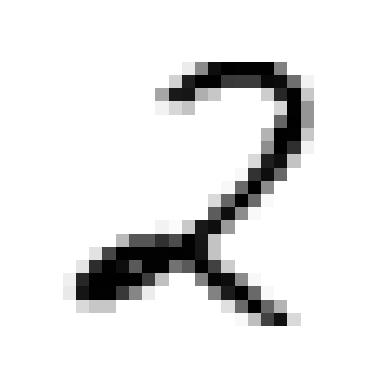

In [4]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

some_digit = X[36009]
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap = matplotlib.cm.binary,
                             interpolation="nearest")
plt.axis("off")
plt.show()

In [5]:
y[36009]

'2'

## The Training and Test Sets

In [6]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [7]:
# Shuffling the training set
import numpy as np

shuffle_index = np.random.permutation(60000)
X_train, y_train = X_train[shuffle_index], y_train[shuffle_index]

## Training a Binary Classifier

In [8]:
# Creating the target vector for the classification task
y_train_2 = (y_train == '2')
y_test_2 = (y_test == '2')

In [9]:
# Let's choose a binary classifier
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_2)

SGDClassifier(random_state=42)

In [10]:
sgd_clf.predict([some_digit])

array([ True])

## Measuring Accuracy Using Cross-Validation

In [11]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_2, cv=3, scoring="accuracy")

array([0.9749, 0.9698, 0.9729])

Never 2 Classifier

In [12]:
from sklearn.base import BaseEstimator

class Never2Classifier(BaseEstimator):
  def fit(self, X, y=None):
    pass
  def predict(self, X):
    return np.zeros((len(X), 1), dtype=bool)

In [13]:
print((y_train_2 == True).sum()/len(y_train_2))

0.0993


## Confusion Matrix

In [14]:
# First we need a set of predictions (to compare with actual targets)
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_2,
                                 cv=3)

In [15]:
# Get the confusion matrix
from sklearn.metrics import confusion_matrix

confusion_matrix(y_train_2, y_train_pred)

array([[53354,   688],
       [  960,  4998]])

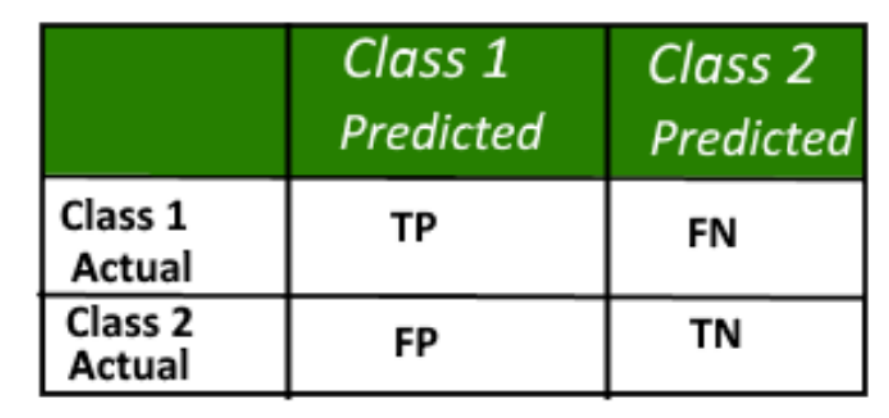

## Precision and Recall

In [16]:
from sklearn.metrics import precision_score, recall_score

precision_score(y_train_2, y_train_pred)

0.8790010552233556

In [17]:
recall_score(y_train_2, y_train_pred)

0.8388721047331319

A more useful combination of both precision and recall is another metric called F1 score.

In [18]:
# A classifier will only get a high F1 score if both precision and recall
# are high.
from sklearn.metrics import f1_score

f1_score(y_train_2, y_train_pred)

0.8584678804534525

In scikit-learn, it is possible to get the scores from the decision function also through cross_val_predict()

In [19]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_2, cv=3,
                             method="decision_function")

Then precision and recall can be computed for all possible thresholds via precision_recall_curve()

In [20]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_2,
                                                         y_scores)

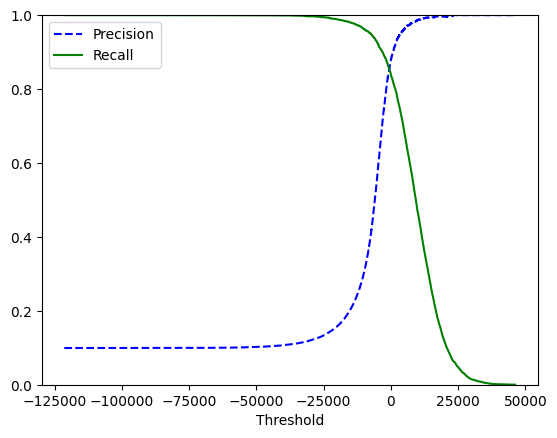

In [21]:
# Plot precision and recall
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
    plt.xlabel("Threshold")
    plt.legend(loc="upper left")
    plt.ylim([0, 1])

plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.show()

## The ROC Curve

In [22]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train_2, y_scores)

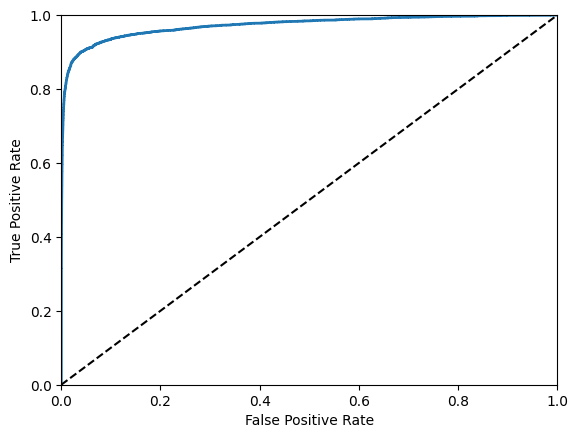

In [23]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.axis([0, 1, 0, 1])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

plot_roc_curve(fpr, tpr)
plt.show()

In [24]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_2, y_scores)

np.float64(0.9723586024168116)

## Multiclass Classification

Multiclass classifiers(also called multinomial classifiers) are capable of classifying between more than two classes.



1.   One-versus-all (OvA) - training a single classifier per class, where labels within that class as positive and all other labels as negative. Then for a given instance, we classify it into the class of the classifier with the highest decision score.


2.   One-versus-one (OvO) - training N(N - 1)/2 classifiers where N are the number of classes:
- class_1, class_2, class_3, ..., class_N
- e.g., for the MNIST data, we need to train 10(10-1)/2 = 45 distinct classifiers



In [25]:
# OneVsAllClassifier
sgd_clf.fit(X_train, y_train)
sgd_clf.predict([some_digit])

array(['2'], dtype='<U1')

In [26]:
sgd_clf.classes_

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype='<U1')

In [27]:
# OneVsOneClassifier
from sklearn.multiclass import OneVsOneClassifier

ovo_clf = OneVsOneClassifier(SGDClassifier(random_state=42))
ovo_clf.fit(X_train, y_train)
ovo_clf.predict([some_digit])

array(['2'], dtype=object)

In [28]:
len(ovo_clf.estimators_)

45

In [29]:
# Evaluate performance
cross_val_score(ovo_clf, X_train, y_train, cv=3,
                scoring="accuracy")

array([0.9134 , 0.9114 , 0.91425])

## Error Analysis

In [30]:
y_train_pred = cross_val_predict(ovo_clf, X_train, y_train,
                                 cv=3)
conf_mx = confusion_matrix(y_train, y_train_pred)
conf_mx

array([[5733,    2,   25,   16,    9,   72,   26,    4,   25,   11],
       [   2, 6464,   82,   36,   10,    8,    4,   19,  108,    9],
       [  57,   57, 5141,  266,   80,   20,   97,   51,  176,   13],
       [  22,   28,   65, 5602,    6,  196,   15,   36,  111,   50],
       [  15,   19,   50,    6, 5375,   10,   42,   37,   18,  270],
       [  94,   18,   29,  275,   36, 4630,  101,    7,  179,   52],
       [  55,    6,   59,    2,   49,   67, 5652,    2,   26,    0],
       [  16,   15,   67,   73,   53,    9,    4, 5694,   25,  309],
       [  40,   78,   55,  242,   21,  173,   40,   18, 5072,  112],
       [  23,   22,   23,   63,  129,   38,    2,  188,   43, 5418]])

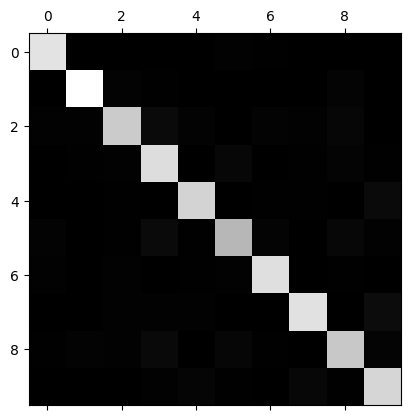

In [31]:
plt.matshow(conf_mx, cmap=plt.cm.gray)
plt.show()

## Multilabel Classification

Suppose that we want to categorise the MNIST handwritten digits into two categories:

- Whether the digit is large (7,8 or 9);
- Whether it is odd(1,3,5,7,9) or even(0,2,4,6,8)

In [32]:
from sklearn.neighbors import KNeighborsClassifier
y_train_int = y_train.astype('int64')

y_train_large = (y_train_int >= 7)
y_train_odd = (y_train_int % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)
knn_clf.predict([some_digit.astype('int64')])

array([[False, False]])

Compute the average of the F1 scores across all the labels as follows

In [36]:
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_train_int,
cv=3)
f1_score(y_train_int, y_train_knn_pred, average="macro")

0.9683927711277962

## Multioutput Classification

Let's make a system that removes noise from images:

We start by artificially adding noise to the pixel intensities of the MNIST test set.

In [37]:
noise = np.random.randint(0, 100, (len(X_train), 784))
X_train_mod =  X_train + noise
noise = np.random.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise
y_train_mod = X_train
y_test_mod = X_test

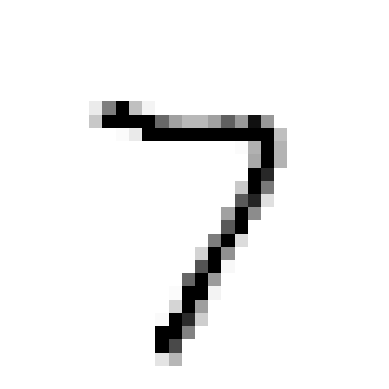

In [40]:
# The clean images
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")
    plt.show()

some_index = 0
knn_clf.fit(X_train_mod, y_train_mod)
clean_digit = knn_clf.predict([X_test_mod[some_index]])
plot_digit(clean_digit)